In [61]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np
import sympy as smp
import scipy.stats as stats

# Normal Distribution

## Standard Normal Distribution

A random variable $Z$ has the $\textbf{standard normal}$ distribution, or $\textbf{standard Gaussian}$ distribution, if $Z$ has the probability density function $$\varphi(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$$ on the real line. Abbreviate this $\mathcal{N}(0,1)$.

Similarly, we use special notation for the standard normal cumulative distribution function: $$\Phi(x) = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{x}e^{-s^2/2}ds \quad x \in \mathcal{R}$$

### Theorem

$$\int_{-\infty}^{\infty}e^{-s^2/2}ds = \sqrt{2\pi}$$

### Proof

$$
\begin{split}
\left( \int_{-\infty}^{\infty}e^{-s^2/2}ds \right)^2 &= \int_{-\infty}^{\infty}e^{-x^2/2}dx \cdot \int_{-\infty}^{\infty}e^{-y^2/2}dy \\
    &= \int_{-\infty}^{\infty}\int_{-\infty}^{\infty}e^{-(x+y)^2/2}dxdy \\
    &= \int_{0}^{2\pi}\int_{0}^{\infty}e^{-r^2/2}rdr{d\theta} \\
    &= \int_{0}^{2\pi} \left( \left. -(e^{-r^2/2} \right|_{r=0}^{r=\infty} \right) {d\theta} \\
    &= \int_{0}^{2\pi} {d\theta} \\
    &= 2\pi
\end{split}
$$

Thus, we see that the fraction $1/\sqrt{2\pi}$ normalizes the exponential term in the standard normal disstribution.

In [62]:
x = smp.symbols('x')
expr = (1/smp.sqrt(2*smp.pi))*(smp.exp(-x**2 / 2))
smp.integrate(expr, (x, -smp.oo, smp.oo))

1

## Normal Distribution

Let $\mu$ be real and $\sigma > 0$. A random variable $X$ has the $\textbf{normal distribution}$ with mean $\mu$ and variance $\sigma^2$ if $X$ has the probability density function $$f(x) = \frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$ on the real line. Abbreviate this $X ~ \mathcal{N}(\mu,\sigma^2)$.

In [63]:
x = smp.symbols('x', real=True)
u = smp.symbols('u', real=True)
s = smp.symbols('s', positive=True)

expr = (1/smp.sqrt(2*smp.pi*s**2))*(smp.exp( -(x-u)**2 / (2*s**2) ))
smp.integrate(expr, (x, -smp.oo, smp.oo))

1

## Central Limit Theorem for Binomial Random Variables

Let $0<p<1$ be fixed and suppose that $S_n \sim Bin(n,p)$. Then, for any fixde $-\infty \leq a \leq b \leq \infty$, we have the limit $$\lim_{n\to\infty} P\left( a \leq \frac{S_n - np}{\sqrt{np(1-p)}} \leq b \right) = \int_{a}^{b} \frac{1}{\sqrt{2\pi}}e^{-x^2/2}dx$$

### Normal Approximation to the Binomial Distribution

As an approximation to the binomial distribution using the normal approximation, suppose we have a large $n$ and $p$ not too close to $0$ or $1$. Then, $$P\left( a \leq \frac{S_n - np}{\sqrt{np(1-p)}} \leq b \right) \text{ is close to } \Phi(b) - \Phi(a)$$ As a rule of thumb, the approximation is good if $np(1-p)>10$.

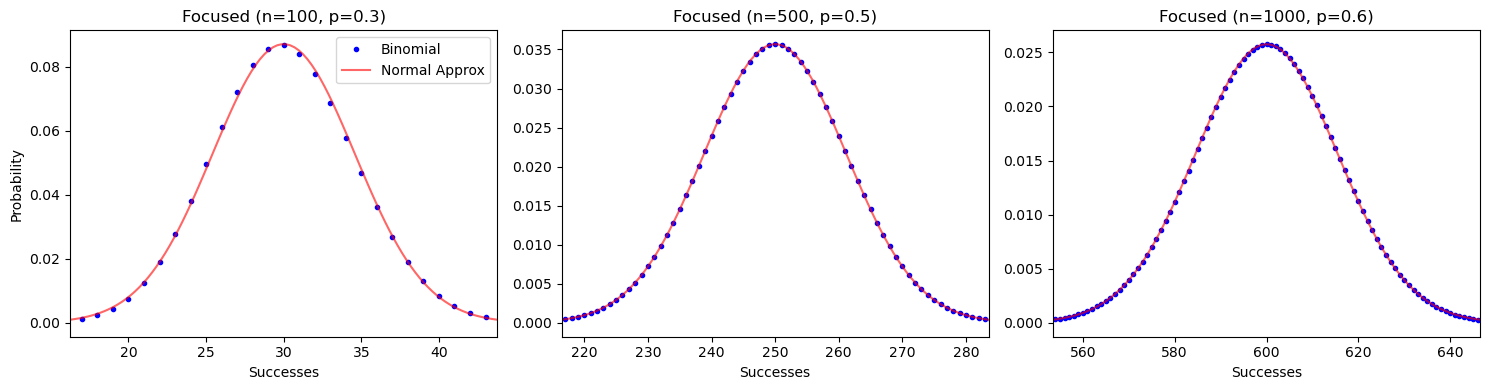

In [64]:
configs = [(100, 0.3), (500, 0.5), (1000, 0.6)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (n, p) in zip(axes, configs):
    x = np.arange(0, n + 1)
    y = stats.binom.pmf(x, n, p)  
    
    # plot binomial data
    ax.plot(x, y, 'b.', label='Binomial')
    
    # calculate mean and standard deviation
    mean = n * p
    std_dev = np.sqrt(n * p * (1 - p))
    
    # set x-axis window (three standard deviations from mean)
    left_bound = mean - 3 * std_dev
    right_bound = mean + 3 * std_dev
    ax.set_xlim(left_bound, right_bound)
    
    # overlay normal distribution
    x_normal = np.linspace(left_bound, right_bound, 100)
    y_normal = stats.norm.pdf(x_normal, mean, std_dev)
    ax.plot(x_normal, y_normal, 'r-', alpha=0.6, label='Normal Approx')
    
    # titles
    ax.set_title(f'Focused (n={n}, p={p})')
    ax.set_xlabel('Successes')

axes[0].set_ylabel('Probability')
axes[0].legend() # Show labels on the first plot

plt.tight_layout()
plt.show()

## Stirling's Formula

As $n\to\infty$, $n! \sim \left(\frac{n}{e}\right)^n\sqrt{2{\pi}n} = n^ne^{-n}\sqrt{2{\pi}n}$.

We can use Stirling's formula for a partial proof of the Central Limit Theorem (CLT) for Binomial Random Variables.  Stirling's formula describes the behavior of $n!$ for large $n$.

## Law of Large Numbers for Binomial Random Variables

Let $S_n \sim Bin(n,p)$. For any fixed $\epsilon > 0$, we have $$P\left( \left| \frac{S_n}{n} - p \right| < \epsilon \right) = 1$$

The observed frequency of success $S_n/n$ will lie within the interval $(p - \epsilon, p + \epsilon)$ with overwhelming probability.

## Application of the Normal Approximation

### Confidence Intervals

In practice we cannot rely on the law of large numbers for the observed probability, $\hat{p}$, to converge. However, we can construct confidence intervals in order to estimate that the error $|\hat{p} - p|$ is bounded by some small margin of error $\epsilon$.

$$
\begin{split}
P\left( |\hat{p} - p| < \epsilon \right) = P\left( |\frac{S_n}{n} - p| < \epsilon \right) &= P\left( -n\epsilon < S_n - np < n\epsilon \right)\\
    &= P\left( -\frac{\epsilon\sqrt{n}}{\sqrt{p(1-p)}} < \frac{S_n - np}{\sqrt{np(1-p)}} < \frac{\epsilon\sqrt{n}}{\sqrt{p(1-p)}} \right)\\
    &\approx \Phi\left( \frac{\epsilon\sqrt{n}}{\sqrt{p(1-p)}} \right) - \Phi\left( -\frac{\epsilon\sqrt{n}}{\sqrt{p(1-p)}} \right)\\
    &= 2\Phi\left( \frac{\epsilon\sqrt{n}}{\sqrt{p(1-p)}} \right) - 1
\end{split}
$$

We know that the maximum value of $p(1-p)$ is $1/4$ for $p=1/2$, which we can confirmm through calculus. Thus, $\frac{\epsilon\sqrt{n}}{\sqrt{p(1-p)}} \geq 2\epsilon\sqrt{n}$. Since the function $\Phi$ is increasing, we have: $$P\left( |\hat{p} - p| < \epsilon \right) \approx 2\Phi\left( \frac{\epsilon\sqrt{n}}{\sqrt{p(1-p)}} \right) - 1 \geq 2\Phi\left( 2\epsilon\sqrt{n} \right) - 1$$

# Poisson Distribution

Let $\lambda > 0$. A random variable $X$ has the $\textbf{Poisson distribution with parameter $\lambda$}$ if $X$ is nonnegative integer valued and has the probability mass function $$P(X=k) = e^{-\lambda}\frac{\lambda^k}{k!} \quad \text{for $k \in \{0, 1, 2, ...\}$}$$
We abbreviate this $X \sim \text{Poisson}(\lambda)$. We have $E[X] = \lambda$ and $Var(X) = \lambda$.

## Law of Rare Events (Binomial Limit Theorem for Poisson)

Let $\lambda > 0$ and consider positive integers $n$ for which $\lambda/n < 1$. Let $S_n \sim Bin(n, \lambda/n)$. Then, $$\lim_{n\to\infty}P(S_n = k) = e^{-\lambda}\frac{\lambda^k}{k!} \quad \text{for all $k \in \{0, 1, 2, ...\}$}$$

### Poisson Approximation to the Binomial Distribution

Let $X \sim Bin(n, p)$ and $Y \sim Poisson(np)$. Then, for any subset $A \subseteq \{0, 1, 2, ...\}$, we have $|P(X \in A) - P(Y \in A)| \leq np^2$.

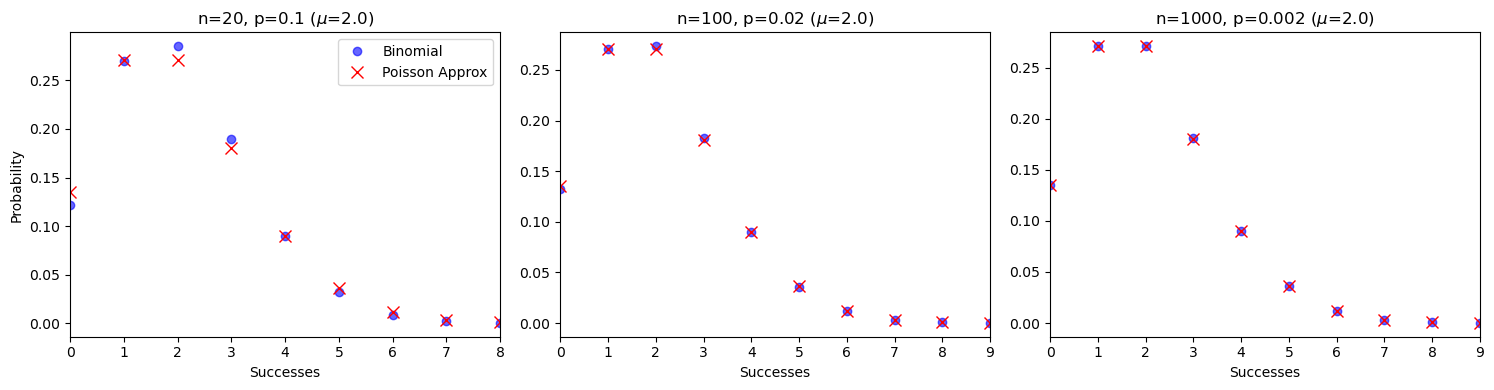

In [65]:
configs = [(20, 0.1), (100, 0.02), (1000, 0.002)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (n, p) in zip(axes, configs):
    # Calculate Poisson mean (mu) and standard deviation from Binomial
    mu = n * p
    binom_mean = n * p
    binom_std = np.sqrt(n * p * (1 - p))
    
    # Set focused x-axis window around the binomial mean
    left_bound = max(0, int(binom_mean - 3 * binom_std))
    right_bound = int(binom_mean + 5 * binom_std)
    
    # x-values for discrete points
    x = np.arange(left_bound, right_bound + 1)
    
    # 1. Plot Binomial data
    y_binom = stats.binom.pmf(x, n, p)  
    ax.plot(x, y_binom, 'bo', label='Binomial', alpha=0.6)
    
    # 2. Overlay Poisson data
    y_poisson = stats.poisson.pmf(x, mu)
    ax.plot(x, y_poisson, 'rx', label='Poisson Approx', markersize=8)
    
    # Formatting
    ax.set_xlim(left_bound, right_bound)
    ax.set_title(f'n={n}, p={p} ($\mu$={mu})')
    ax.set_xlabel('Successes')

axes[0].set_ylabel('Probability')
axes[0].legend()

plt.tight_layout()
plt.show()